# GSE284089 — Visium Spatial Transcriptomics

This notebook wrangles the GEO supplementary files from **GSE284089** (sample `GSM8677818`) into a KaroSpace-ready AnnData object.

The raw download contains GEO-prefixed files that correspond to a standard 10x Space Ranger output. The notebook:

1. Reconstructs the expected Space Ranger directory layout from the GEO files.
2. Loads the data with `scanpy.read_visium()`.
3. Runs QC, normalization, HVG selection, PCA, clustering, and UMAP.
4. Visualizes clusters in UMAP and spatial coordinates.
5. Optionally saves the processed `.h5ad`.

Configured data directory: `/Users/chrislangseth/Downloads/GSE284089_RAW`

In [36]:
from __future__ import annotations

import gzip
import json
import os
import shutil
from pathlib import Path
from pprint import pprint

os.environ.setdefault("KMP_WARNINGS", "0")

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import squidpy as sq

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 60)

PROJECT_ROOT = Path("/Users/chrislangseth/work/karolinska_institutet/projects/KaroSpaceDataWrangling")
GEO_RAW_DIR = Path("/Users/chrislangseth/Downloads/GSE284089_RAW")
SAMPLE_PREFIX = "GSM8677818"

CACHE_DIR = PROJECT_ROOT / "data" / "geo_cache" / "GSE284089" / SAMPLE_PREFIX
OUTPUT_DIR = PROJECT_ROOT / "data" / "processed" / "GSE284089"
OUTPUT_PATH = OUTPUT_DIR / f"{SAMPLE_PREFIX}.h5ad"

WRITE_OUTPUT = True

GEO_RAW_DIR.exists(), sorted(p.name for p in GEO_RAW_DIR.iterdir() if not p.name.startswith("."))

(True,
 ['GSM8677818_barcodes.tsv.gz',
  'GSM8677818_features.tsv.gz',
  'GSM8677818_filtered_feature_bc_matrix.h5',
  'GSM8677818_matrix.mtx.gz',
  'GSM8677818_scalefactors_json.json.gz',
  'GSM8677818_spatial_enrichment.csv.gz',
  'GSM8677818_tissue_hires_image.png',
  'GSM8677818_tissue_hires_image.png.gz',
  'GSM8677818_tissue_lowres_image.png',
  'GSM8677818_tissue_lowres_image.png.gz',
  'GSM8677818_tissue_positions.csv.gz'])

## Reconstruct Space Ranger layout

`scanpy.read_visium()` expects a directory with `filtered_feature_bc_matrix.h5` and a `spatial/` subfolder containing scale factors, tissue positions, and tissue images. The GEO download has all the right files but with a sample prefix and gzip compression. The next cell decompresses and renames them into the expected layout under a local cache directory.

In [37]:
def _decompress_gz(src: Path, dst: Path) -> None:
    """Decompress a .gz file to dst."""
    with gzip.open(src, "rb") as f_in, open(dst, "wb") as f_out:
        shutil.copyfileobj(f_in, f_out)


# Mapping from GEO-prefixed filenames to the Space Ranger layout
SPATIAL_DIR = CACHE_DIR / "spatial"
FILE_MAP = {
    # Main matrix (already .h5, not gzipped)
    GEO_RAW_DIR / f"{SAMPLE_PREFIX}_filtered_feature_bc_matrix.h5": CACHE_DIR / "filtered_feature_bc_matrix.h5",
    # Spatial files (gzipped → decompress into spatial/)
    GEO_RAW_DIR / f"{SAMPLE_PREFIX}_scalefactors_json.json.gz": SPATIAL_DIR / "scalefactors_json.json",
    GEO_RAW_DIR / f"{SAMPLE_PREFIX}_tissue_positions.csv.gz": SPATIAL_DIR / "tissue_positions.csv",
    GEO_RAW_DIR / f"{SAMPLE_PREFIX}_tissue_hires_image.png.gz": SPATIAL_DIR / "tissue_hires_image.png",
    GEO_RAW_DIR / f"{SAMPLE_PREFIX}_tissue_lowres_image.png.gz": SPATIAL_DIR / "tissue_lowres_image.png",
}

SPATIAL_DIR.mkdir(parents=True, exist_ok=True)

for src, dst in FILE_MAP.items():
    if dst.exists():
        continue
    if not src.exists():
        raise FileNotFoundError(f"Missing source file: {src}")
    if src.suffix == ".gz":
        _decompress_gz(src, dst)
        print(f"  decompressed {src.name} → {dst.relative_to(CACHE_DIR)}")
    else:
        shutil.copy2(src, dst)
        print(f"  copied {src.name} → {dst.relative_to(CACHE_DIR)}")

# Also copy the uncompressed images if they exist (GEO sometimes includes both)
for img_name in ["tissue_hires_image.png", "tissue_lowres_image.png"]:
    raw_img = GEO_RAW_DIR / f"{SAMPLE_PREFIX}_{img_name}"
    target = SPATIAL_DIR / img_name
    if raw_img.exists() and not target.exists():
        shutil.copy2(raw_img, target)
        print(f"  copied {raw_img.name} → spatial/{img_name}")

print(f"\nCache directory: {CACHE_DIR}")
print("Contents:")
for p in sorted(CACHE_DIR.rglob("*")):
    if p.is_file():
        print(f"  {p.relative_to(CACHE_DIR)}  ({p.stat().st_size:,} bytes)")


Cache directory: /Users/chrislangseth/work/karolinska_institutet/projects/KaroSpaceDataWrangling/data/geo_cache/GSE284089/GSM8677818
Contents:
  filtered_feature_bc_matrix.h5  (1,462,436 bytes)
  spatial/scalefactors_json.json  (197 bytes)
  spatial/tissue_hires_image.png  (5,009,803 bytes)
  spatial/tissue_lowres_image.png  (516,226 bytes)
  spatial/tissue_positions.csv  (181,830 bytes)


## Load with `scanpy.read_visium()`

In [38]:
adata = sc.read_visium(CACHE_DIR)
adata.var_names_make_unique()

print(adata)
print(f"obsm keys: {list(adata.obsm.keys())}")
print(f"uns keys:  {list(adata.uns.keys())}")
adata.obs.head()

/var/folders/5b/5bpdw2nj10d6gxym7gcl01hh0000gp/T/ipykernel_56950/472179004.py:1: FutureWarning: Use `squidpy.read.visium` instead.
  adata = sc.read_visium(CACHE_DIR)
/Users/chrislangseth/miniforge3/envs/cellcharter/lib/python3.11/site-packages/anndata/_core/anndata.py:1808: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/Users/chrislangseth/miniforge3/envs/cellcharter/lib/python3.11/site-packages/anndata/_core/anndata.py:1808: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


AnnData object with n_obs × n_vars = 4992 × 18085
    obs: 'in_tissue', 'array_row', 'array_col'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatial'
    obsm: 'spatial'
obsm keys: ['spatial']
uns keys:  ['spatial']


,in_tissue,array_row,array_col
AACACCTACTATCGAA-1,1,0,122
AACACGTGCATCGCAC-1,1,76,22
AACACTTGGCAAGGAA-1,1,47,71
AACAGGAAGAGCATAG-1,1,69,7
AACAGGATTCATAGTT-1,1,49,43


/var/folders/5b/5bpdw2nj10d6gxym7gcl01hh0000gp/T/ipykernel_56950/2924959034.py:2: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata, img_key="hires", color=None, size=1.2)


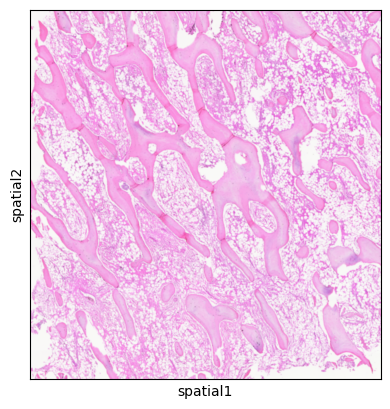

In [39]:
# Quick spatial sanity check
sc.pl.spatial(adata, img_key="hires", color=None, size=1.2)

## QC

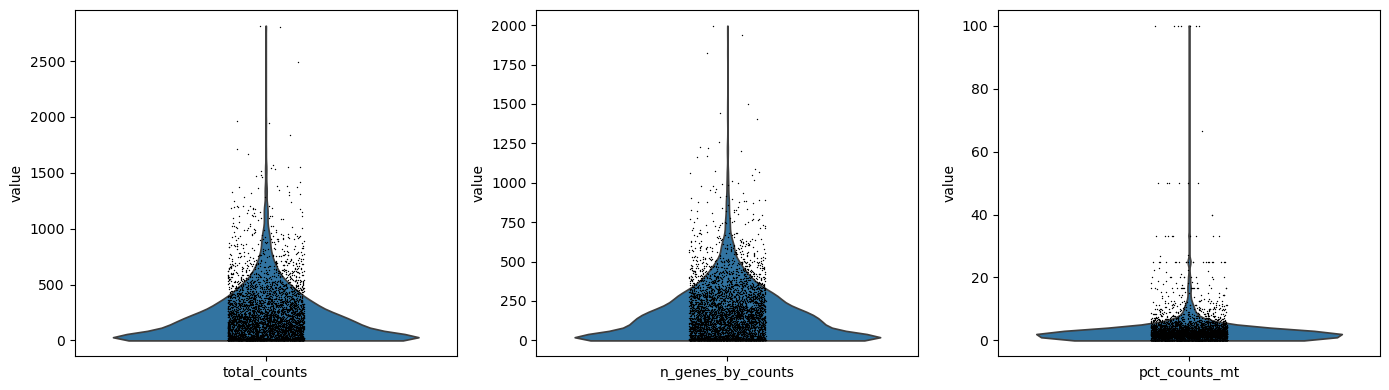

,total_counts,n_genes_by_counts,pct_counts_mt
count,4992.000000,4992.000000,4849.000000
mean,214.205322,166.395833,2.946347
std,247.170609,179.706125,5.461264
min,0.000000,0.000000,0.000000
25%,27.000000,25.000000,0.769231
50%,144.000000,121.000000,2.040816
75%,313.000000,248.000000,3.414634
max,2816.000000,1996.000000,100.000000


In [40]:
adata.var["mt"] = adata.var_names.str.upper().str.startswith("MT-")
sc.pp.calculate_qc_metrics(adata, qc_vars=["mt"], percent_top=None, log1p=False, inplace=True)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
sc.pl.violin(adata, "total_counts", ax=axes[0], show=False)
sc.pl.violin(adata, "n_genes_by_counts", ax=axes[1], show=False)
sc.pl.violin(adata, "pct_counts_mt", ax=axes[2], show=False)
plt.tight_layout()
plt.show()

adata.obs[["total_counts", "n_genes_by_counts", "pct_counts_mt"]].describe()

/var/folders/5b/5bpdw2nj10d6gxym7gcl01hh0000gp/T/ipykernel_56950/1563000558.py:1: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata, img_key="hires", color=["total_counts", "n_genes_by_counts", "pct_counts_mt"], size=1.2, ncols=3)


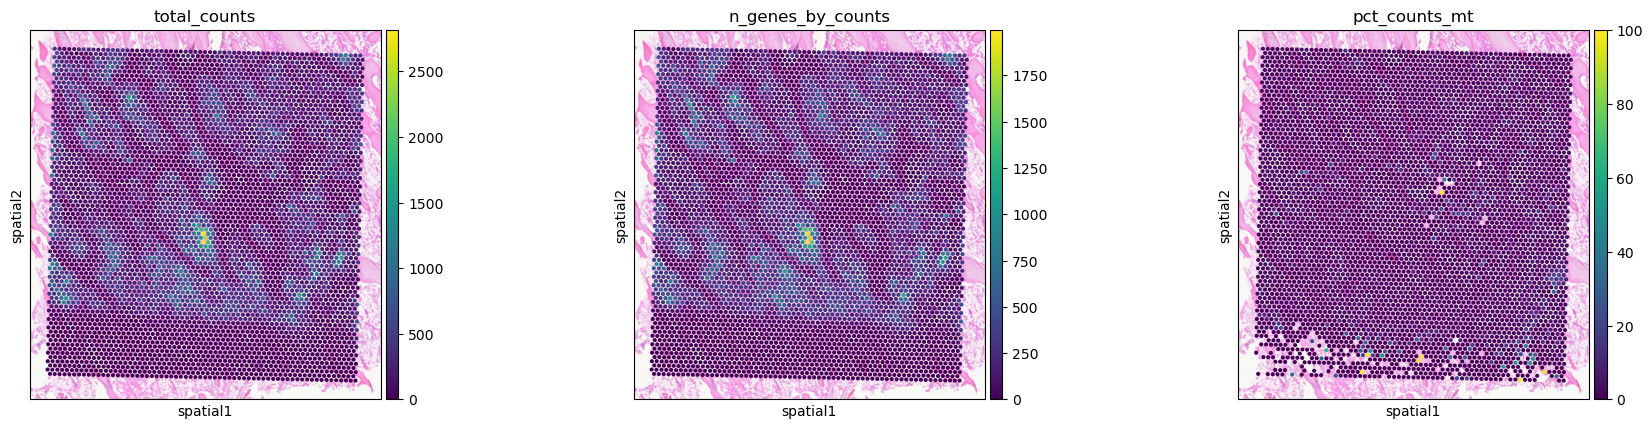

In [41]:
sc.pl.spatial(adata, img_key="hires", color=["total_counts", "n_genes_by_counts", "pct_counts_mt"], size=1.2, ncols=3)

## Filtering and normalization

In [42]:
# Filter spots that are under tissue
adata = adata[adata.obs["in_tissue"] == 1].copy()
print(f"Spots in tissue: {adata.n_obs}")

sc.pp.filter_genes(adata, min_counts=3)
sc.pp.filter_cells(adata, min_counts=3)
print(f"After filtering: {adata.n_obs} spots x {adata.n_vars} genes")

adata.layers["counts"] = adata.X.copy()

sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
adata.raw = adata.copy()

adata

Spots in tissue: 4992
After filtering: 4554 spots x 15401 genes


AnnData object with n_obs × n_vars = 4554 × 15401
    obs: 'in_tissue', 'array_row', 'array_col', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_counts'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_counts'
    uns: 'spatial', 'log1p'
    obsm: 'spatial'
    layers: 'counts'

## HVG selection, PCA, clustering, UMAP

In [43]:
n_top_genes = min(5000, adata.n_vars)
sc.pp.highly_variable_genes(adata, n_top_genes=n_top_genes, flavor="seurat", subset=True)

sc.tl.pca(adata, svd_solver="arpack")
sc.pp.neighbors(adata, n_neighbors=15, n_pcs=min(30, adata.obsm["X_pca"].shape[1]))
sc.tl.umap(adata, min_dist=0.3)
sc.tl.leiden(adata, resolution=1.0, key_added="leiden_1.0")

adata

AnnData object with n_obs × n_vars = 4554 × 5000
    obs: 'in_tissue', 'array_row', 'array_col', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_counts', 'leiden_1.0'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'spatial', 'log1p', 'hvg', 'pca', 'neighbors', 'umap', 'leiden_1.0'
    obsm: 'spatial', 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'distances', 'connectivities'

## Visualization

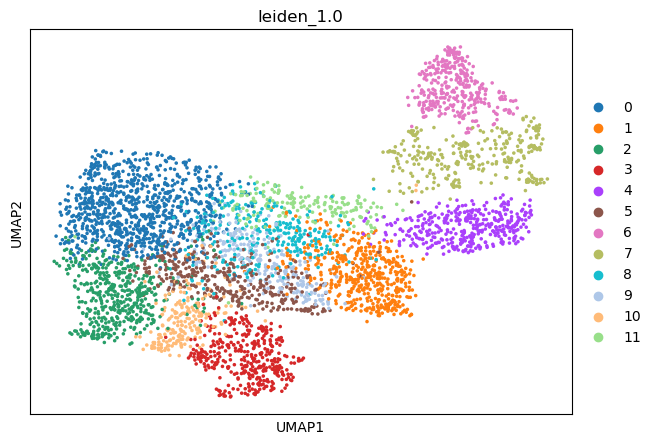

In [44]:
with plt.rc_context({"figure.figsize": (7, 5)}):
    sc.pl.umap(adata, color=["leiden_1.0"], wspace=0.4)

/var/folders/5b/5bpdw2nj10d6gxym7gcl01hh0000gp/T/ipykernel_56950/3654970403.py:1: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata, img_key="hires", color="leiden_1.0", size=1.2)


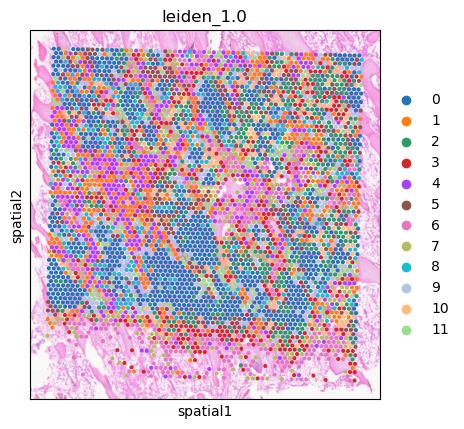

In [45]:
sc.pl.spatial(adata, img_key="hires", color="leiden_1.0", size=1.2)

## Spatial neighbors (Squidpy)

In [46]:
sq.gr.spatial_neighbors(adata, coord_type="grid", delaunay=True)

## Spatial enrichment (from GEO)

The GEO download includes a precomputed spatial enrichment table. Load it for reference.

In [47]:
spatial_enrichment = pd.read_csv(GEO_RAW_DIR / f"{SAMPLE_PREFIX}_spatial_enrichment.csv.gz")
print(f"Spatial enrichment table: {spatial_enrichment.shape}")
spatial_enrichment.head(10)

Spatial enrichment table: (17456, 9)


,Feature ID,Feature Name,Feature Type,I,P value,Adjusted p value,Feature Counts in Spots Under Tissue,Median Normalized Average Counts,Barcodes Detected per Feature
0,ENSG00000211592,IGKC,Gene Expression,0.423882,0.0,0.0,73516,7.692440,3505
1,ENSG00000108821,COL1A1,Gene Expression,0.374341,0.0,0.0,16204,2.456216,2767
2,ENSG00000211895,IGHA1,Gene Expression,0.356719,0.0,0.0,21368,2.343402,2633
3,ENSG00000211899,IGHM,Gene Expression,0.335799,0.0,0.0,11952,1.295601,1851
4,ENSG00000211896,IGHG1,Gene Expression,0.300249,0.0,0.0,10199,1.161511,1964
5,ENSG00000164692,COL1A2,Gene Expression,0.261462,0.0,0.0,8742,1.328757,2445
6,ENSG00000211897,IGHG3,Gene Expression,0.229905,0.0,0.0,649,0.097804,201
7,ENSG00000118785,SPP1,Gene Expression,0.219537,0.0,0.0,2465,0.429254,1042
8,ENSG00000113140,SPARC,Gene Expression,0.215299,0.0,0.0,4346,0.658592,1798
9,ENSG00000168542,COL3A1,Gene Expression,0.207049,0.0,0.0,7207,0.987316,2432


## Optional save

In [48]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

if WRITE_OUTPUT:
    adata.write_h5ad(OUTPUT_PATH)
    print(f"Wrote: {OUTPUT_PATH}")
else:
    print(f"WRITE_OUTPUT is False — set to True to save.")
    print(f"Planned output: {OUTPUT_PATH}")

Wrote: /Users/chrislangseth/work/karolinska_institutet/projects/KaroSpaceDataWrangling/data/processed/GSE284089/GSM8677818.h5ad


In [51]:
adata.obsm

AxisArrays with keys: spatial, X_pca, X_umap